In [1]:
%reload_ext autoreload
%autoreload 2

### 1. Load an example: retrieve a 2D position from the `IntervalPositionInfo` table

First we specify the nwb file and get the name of the copied version (without the ephys data) that is used as a key.

In [160]:
import spyglass as nd
import matplotlib.pyplot as plt
import spyglass as nd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.common import IntervalList
from spyglass.common.common_position import IntervalPositionInfo
from spyglass.common.common_position import IntervalPositionInfoSelection
from spyglass.common.common_position import IntervalLinearizationSelection
from spyglass.common.common_position import IntervalLinearizedPosition
from spyglass.common.common_position import TrackGraph
from spyglass.shijiegu.Analysis_SGU import get_linearization_map, ChangeofMind, ChangeofMindTheta

from spyglass.common.common_position import TrackGraph

graph = TrackGraph() & {'track_graph_name': '4 arm lumped 2023'}
linear_map,welllocations=get_linearization_map()
print(linear_map)
nodes=linear_map.reshape((-1,1))
wellnames=list(welllocations.keys())[1:]
wells=list(welllocations.values())
_,linear_map_ind,__=np.intersect1d(linear_map[:,1],wells[1:],return_indices=True)
linear_map_ind

nwb_file_name = 'lewis20240109.nwb'
nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)
nwb_copy_file_name

[12:00:30][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[12:00:30][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


[[  0.          57.63896252]
 [ 57.63896252  91.42227941]
 [131.42227941 165.66041604]
 [165.66041604 252.64353221]
 [292.64353221 331.10211383]
 [331.10211383 418.29227956]
 [458.29227956 496.49241045]
 [496.49241045 583.18763812]
 [623.18763812 657.72023142]
 [657.72023142 743.03215907]]


'lewis20240109_.nwb'

Now specify an example position interval we want to look at.

In [98]:
IntervalPositionInfo & {'nwb_file_name': nwb_copy_file_name}

position_info_param_name name for this set of parameters,nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list,analysis_file_name name of the file,head_position_object_id,head_orientation_object_id,head_velocity_object_id
default,lewis20240109_.nwb,pos 0 valid times,lewis20240109_GIRUA59WMK.nwb,5d5dd480-c01b-4a0e-bf6e-8269812277e6,53f522c6-11dc-4621-aab0-0d569dab7d98,ad9d2dd1-c875-4a17-952c-5359b95944ba
default,lewis20240109_.nwb,pos 1 valid times,lewis20240109_R4LWKFUE59.nwb,3dffc883-db7f-48ef-884a-cb578ee2b945,108c8558-8cf2-4c13-ba69-278c49a9d0cd,ec6afb48-87bd-4457-a26d-e9c2be950cbe
default,lewis20240109_.nwb,pos 2 valid times,lewis20240109_HODGCFPO5I.nwb,6d169ba5-bc2a-4679-adf8-9c8f6dfe9cee,f83782b9-e295-4e90-b333-99f5c007d497,d919bc24-2ee3-4900-8587-0a0ea9f06b11
default,lewis20240109_.nwb,pos 3 valid times,lewis20240109_3IZMWIDEKI.nwb,b1c17bb7-d8e5-40a9-8a09-57ea076d7504,e4fc9108-0556-4cac-b145-24f1b78ad491,71767291-91d1-41b3-8709-3051003d06d0
default,lewis20240109_.nwb,pos 4 valid times,lewis20240109_CFAIR1U73V.nwb,bff7dddf-add8-4cca-accb-2779ce56fc78,653ccad1-bca2-4331-a815-7aa1a9c7f24a,abf363c5-14d6-4e5b-96ec-867a0fd812c9
default,lewis20240109_.nwb,pos 5 valid times,lewis20240109_JNHAGABYXZ.nwb,f1dac574-e36f-4851-9aba-fb76aada8241,65f9f9dc-9618-4859-a1a8-ea7baf5445dc,ba23aa21-28ff-46b5-891e-f857a864fc68
default,lewis20240109_.nwb,pos 6 valid times,lewis20240109_S6B85GO1KF.nwb,49b58e49-13c6-48cb-ad56-ac57e1eb879a,af26a61d-c9f9-442d-8902-45b1795085a5,c175d33a-8280-49b3-8d9c-d6b9a543868b
default,lewis20240109_.nwb,pos 7 valid times,lewis20240109_Y30OYJQ217.nwb,328036ea-bb6f-4dc5-8080-537686177808,63f6fda7-e502-4f7d-b783-48c1473839f7,046a1fa1-a165-4de0-8836-1be61ff036d1
default,lewis20240109_.nwb,pos 8 valid times,lewis20240109_9YGJVQXZH7.nwb,e86b13d0-8e41-4fa8-b0fb-51b1c12a3fe5,213ddf3a-e85c-403c-82d8-d10dd168d47f,4df77323-5617-4716-92b6-112a2d70287a
default_decoding,lewis20240109_.nwb,pos 0 valid times,lewis20240109_UTJEDJIJ2Q.nwb,af2a964d-5914-4c6d-8dfd-03daff5d941d,3bded081-127b-4fba-9020-2c5eca0205eb,8618e2a0-a72c-4cf0-8cbb-b22489e191b0


### Epoch and trial number

In [123]:
epoch = 4
interval_list_name = "pos 3 valid times"

In [124]:
key = {'nwb_file_name': nwb_copy_file_name, "epoch": epoch, "proportion": 0.1}
log = ChangeofMindTheta().fetch1_dataframe(key)

[2025-10-04 11:46:58,618][WARNING]: Skipped checksum for file with hash: 0d13cdf6-5436-9a97-68ea-0eb3849664c5, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_XZOX9O55PQ.nwb


In [133]:
log[log.change_of_mind]

,timestamp_H,Home,timestamp_O,OuterWellIndex,rewardNum,change_of_mind,theta_dev,long_theta,CoMMaxProportion,initial_choice,...,proportion_arm2,proportion_arm3,proportion_arm4,CoMNum_by_time,CoMNum_by_arm,current,future_H,future_O,past,past_reward
id,,,,,,,,,,,,,,,,,,,,,
11,1.704833e+09,1.0,1.704833e+09,2.0,2.0,True,0,False,0.552658,3.0,...,0.000000,0.552658,0.000000,1,1,2.0,2.0,4.0,1.0,1.0
13,1.704833e+09,1.0,1.704833e+09,3.0,2.0,True,0,False,0.578062,1.0,...,0.111066,0.000000,0.000000,2,2,3.0,3.0,1.0,4.0,4.0
14,1.704833e+09,1.0,1.704833e+09,1.0,2.0,True,0,False,0.134795,2.0,...,0.134795,0.000000,0.000000,1,1,1.0,1.0,2.0,3.0,3.0
28,1.704833e+09,1.0,1.704833e+09,3.0,1.0,True,0,False,0.106553,4.0,...,0.000000,0.000000,0.106553,1,1,3.0,3.0,4.0,2.0,2.0
39,1.704834e+09,1.0,1.704834e+09,3.0,2.0,True,0,False,0.607114,3.0,...,0.607114,0.000000,0.000000,2,1,3.0,3.0,1.0,1.0,4.0
41,1.704834e+09,1.0,1.704834e+09,4.0,1.0,True,0,False,1.000000,3.0,...,0.000000,1.000000,0.000000,2,1,4.0,4.0,2.0,1.0,1.0
43,1.704834e+09,1.0,1.704834e+09,3.0,1.0,True,0,False,0.334493,3.0,...,0.000000,0.000000,0.000000,2,1,3.0,3.0,4.0,2.0,2.0
44,1.704834e+09,1.0,1.704834e+09,4.0,2.0,True,0,False,0.647582,1.0,...,0.000000,0.000000,0.000000,1,1,4.0,4.0,3.0,3.0,2.0
45,1.704834e+09,1.0,1.704834e+09,3.0,2.0,True,0,False,0.548515,2.0,...,0.548515,0.000000,0.000000,1,1,3.0,3.0,1.0,4.0,4.0


### Change of mind trials

In [132]:
position2d = (IntervalPositionInfo() &
                 {'nwb_file_name': nwb_copy_file_name,
                  'interval_list_name': interval_list_name,
                  'position_info_param_name': 'default'}
                ).fetch1_dataframe()

position1d = (IntervalLinearizedPosition() &
                 {'nwb_file_name': nwb_copy_file_name,
                  'interval_list_name': interval_list_name,
                  'position_info_param_name': 'default'}
                ).fetch1_dataframe()

[2025-10-04 11:50:02,539][WARNING]: Skipped checksum for file with hash: 5e53189b-9f7d-31ef-a7ea-580dd9eaadbd, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_3IZMWIDEKI.nwb
[2025-10-04 11:50:02,563][WARNING]: Skipped checksum for file with hash: 5e53189b-9f7d-31ef-a7ea-580dd9eaadbd, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_3IZMWIDEKI.nwb
[2025-10-04 11:50:02,571][WARNING]: Skipped checksum for file with hash: 5e53189b-9f7d-31ef-a7ea-580dd9eaadbd, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_3IZMWIDEKI.nwb
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.6.0-alpha because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'ndx-franklab-nove

In [181]:
trialID = 45
t0 = log.loc[trialID].timestamp_H
t1 = log.loc[trialID].timestamp_O

subset_ind = (position2d.index >= t0) & (position2d.index <= t1)
position2d_subset = position2d.loc[subset_ind]

subset_ind = (position1d.index >= t0) & (position1d.index <= t1)
position1d_subset = position1d.loc[subset_ind]

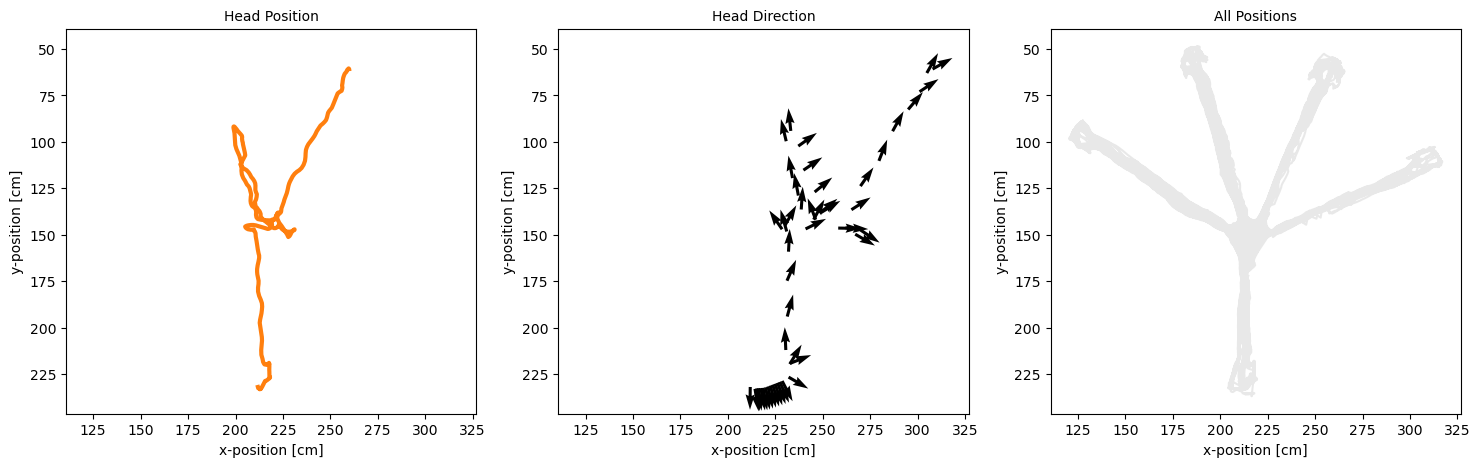

In [182]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(position2d.head_position_x,
        position2d.head_position_y, color='lightgrey',alpha = 0.0001)
ax.plot(position2d_subset.head_position_x,
        position2d_subset.head_position_y, color='C1',linewidth = 3)
ax.set_xlabel('x-position [cm]', fontsize=10)
ax.set_ylabel('y-position [cm]', fontsize=10)
ax.set_title('Head Position', fontsize=10)
ax.invert_yaxis()

ax = axes[1]
ax.plot(position2d.head_position_x,
        position2d.head_position_y, color='lightgrey',alpha = 0.0001)
quiver_subsample = 10
ax.quiver(position2d_subset.head_position_x[::quiver_subsample] +  np.arange(len(position2d_subset.head_position_x[::quiver_subsample])), 
          position2d_subset.head_position_y[::quiver_subsample],
          np.cos(position2d_subset.head_orientation[::quiver_subsample]),
          -np.sin(position2d_subset.head_orientation[::quiver_subsample]),
         )
ax.set_xlabel('x-position [cm]', fontsize=10)
ax.set_ylabel('y-position [cm]', fontsize=10)
ax.set_title('Head Direction', fontsize=10)
ax.invert_yaxis()

ax = axes[2]
ax.plot(position2d.head_position_x,
        position2d.head_position_y, color='lightgrey',alpha = 0.5)
ax.set_xlabel('x-position [cm]', fontsize=10)
ax.set_ylabel('y-position [cm]', fontsize=10)
ax.set_title('All Positions', fontsize=10)
ax.invert_yaxis()
plt.savefig(f"figure1/{nwb_copy_file_name}_epoch{epoch}_trial{trialID}.pdf")
plt.savefig(f"figure1/{nwb_copy_file_name}_epoch{epoch}_trial{trialID}.png")

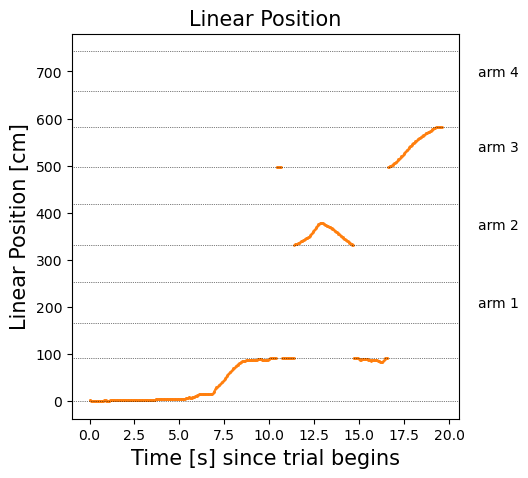

In [183]:
fig, ax = plt.subplots(figsize=(5, 5))

for w in range(len(linear_map_ind)):
    plt.axhline(y=linear_map[linear_map_ind[w],0],linestyle='dotted',lw=0.5,color='k')
    plt.axhline(y=linear_map[linear_map_ind[w],1],linestyle='dotted',lw=0.5,color='k')
    plt.text(position1d_subset.index[-1]-position1d_subset.index[0]+2,
             np.mean(linear_map[linear_map_ind[w],:])-10,'arm '+wellnames[w][4],fontsize=10)
    
plt.axhline(y=0,linestyle='dotted',lw=0.5,color='k')
plt.axhline(y=linear_map[1,1],linestyle='dotted',lw=0.5,color='k')
    
ax.scatter(position1d_subset.index-position1d_subset.index[0],
           position1d_subset.linear_position,
           c='C1',
           s=1)

# graph.plot_track_graph_as_1D(
#     ax=ax,
#     axis='y',
#     other_axis_start=linear_position_info.iloc[interval_index].index[-1] + 10)

ax.set_xlabel('Time [s] since trial begins', fontsize=15)
ax.set_ylabel('Linear Position [cm]', fontsize=15)#,labelpad=70)
ax.set_title('Linear Position', fontsize=15)
plt.savefig(f"figure1/{nwb_copy_file_name}_epoch{epoch}_trial{trialID}_linear.pdf")

### Non change of mind trials

In [185]:
trialID = 46
t0 = log.loc[trialID].timestamp_H
t1 = log.loc[trialID].timestamp_O

subset_ind = (position2d.index >= t0) & (position2d.index <= t1)
position2d_subset = position2d.loc[subset_ind]

subset_ind = (position1d.index >= t0) & (position1d.index <= t1)
position1d_subset = position1d.loc[subset_ind]

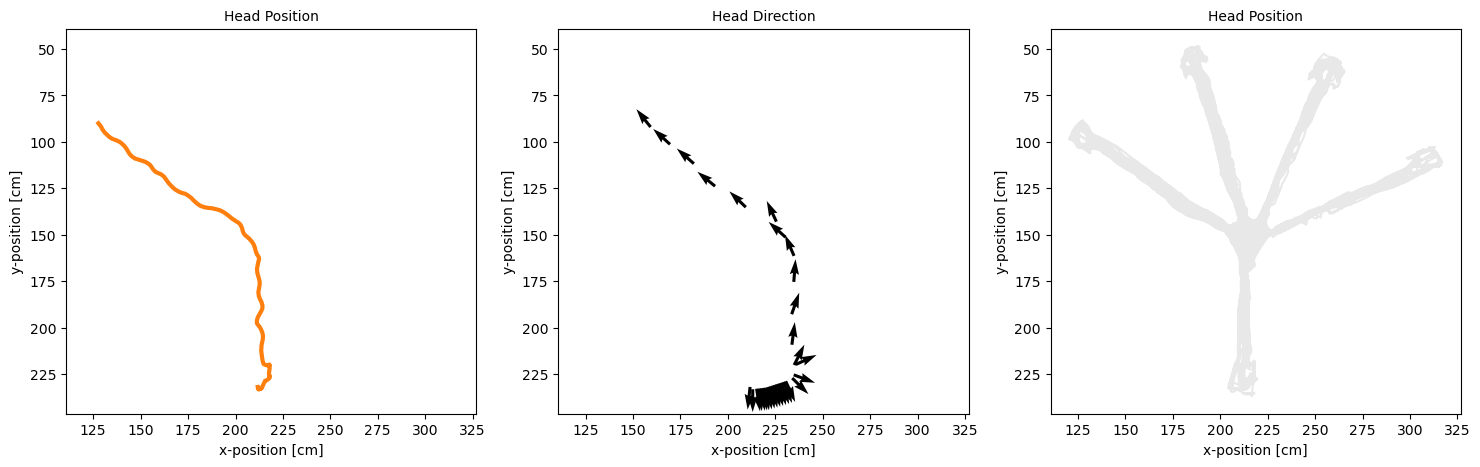

In [186]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(position2d.head_position_x,
        position2d.head_position_y, color='lightgrey',alpha = 0.0001)
ax.plot(position2d_subset.head_position_x,
        position2d_subset.head_position_y, color='C1',linewidth = 3)
ax.set_xlabel('x-position [cm]', fontsize=10)
ax.set_ylabel('y-position [cm]', fontsize=10)
ax.set_title('Head Position', fontsize=10)
ax.invert_yaxis()

ax = axes[1]
ax.plot(position2d.head_position_x,
        position2d.head_position_y, color='lightgrey',alpha = 0.0001)
quiver_subsample = 10
ax.quiver(position2d_subset.head_position_x[::quiver_subsample] +  np.arange(len(position2d_subset.head_position_x[::quiver_subsample])), 
          position2d_subset.head_position_y[::quiver_subsample],
          np.cos(position2d_subset.head_orientation[::quiver_subsample]),
          -np.sin(position2d_subset.head_orientation[::quiver_subsample]),
         )
ax.set_xlabel('x-position [cm]', fontsize=10)
ax.set_ylabel('y-position [cm]', fontsize=10)
ax.set_title('Head Direction', fontsize=10)
ax.invert_yaxis()

ax = axes[2]
ax.plot(position2d.head_position_x,
        position2d.head_position_y, color='lightgrey',alpha = 0.5)
ax.set_xlabel('x-position [cm]', fontsize=10)
ax.set_ylabel('y-position [cm]', fontsize=10)
ax.set_title('Head Position', fontsize=10)
ax.invert_yaxis()

plt.savefig(f"figure1/{nwb_copy_file_name}_epoch{epoch}_trial{trialID}.png")
plt.savefig(f"figure1/{nwb_copy_file_name}_epoch{epoch}_trial{trialID}.pdf")

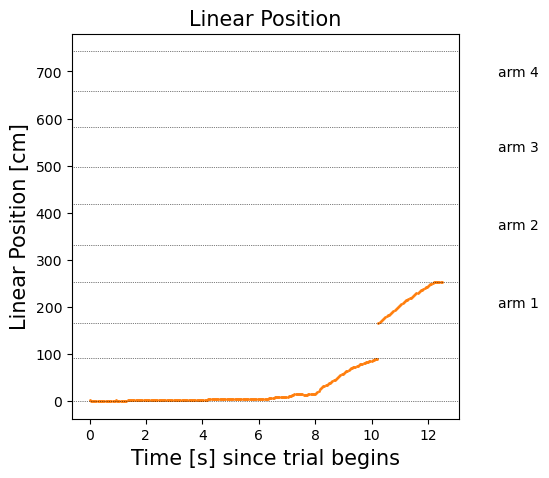

In [176]:
fig, ax = plt.subplots(figsize=(5, 5))

for w in range(len(linear_map_ind)):
    plt.axhline(y=linear_map[linear_map_ind[w],0],linestyle='dotted',lw=0.5,color='k')
    plt.axhline(y=linear_map[linear_map_ind[w],1],linestyle='dotted',lw=0.5,color='k')
    plt.text(position1d_subset.index[-1]-position1d_subset.index[0]+2,
             np.mean(linear_map[linear_map_ind[w],:])-10,'arm '+wellnames[w][4],fontsize=10)
    
plt.axhline(y=0,linestyle='dotted',lw=0.5,color='k')
plt.axhline(y=linear_map[1,1],linestyle='dotted',lw=0.5,color='k')
    
ax.scatter(position1d_subset.index-position1d_subset.index[0],
           position1d_subset.linear_position,
           c='C1',
           s=1)

# graph.plot_track_graph_as_1D(
#     ax=ax,
#     axis='y',
#     other_axis_start=linear_position_info.iloc[interval_index].index[-1] + 10)

ax.set_xlabel('Time [s] since trial begins', fontsize=15)
ax.set_ylabel('Linear Position [cm]', fontsize=15)#,labelpad=70)
ax.set_title('Linear Position', fontsize=15)

plt.savefig(f"figure1/{nwb_copy_file_name}_epoch{epoch}_trial{trialID}_linear.pdf")

### End here

Text(0.5, 1.0, 'Linear Position')

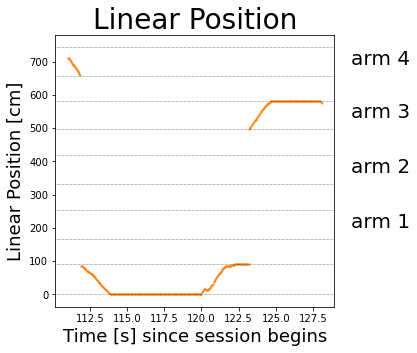

In [129]:
fig, ax = plt.subplots(figsize=(5, 5))

# for i in range(len(nodes)):
#     plt.axhline(y=nodes[i],linestyle='dotted',lw=0.2)
for w in range(len(linear_map_ind)):
    plt.axhline(y=linear_map[linear_map_ind[w],0],linestyle='dotted',lw=0.5,color='k')
    plt.axhline(y=linear_map[linear_map_ind[w],1],linestyle='dotted',lw=0.5,color='k')
    plt.text(linear_position_info.iloc[interval_index].index[-1]-linear_position_info.index[0]+2,
             np.mean(linear_map[linear_map_ind[w],:])-10,'arm '+wellnames[w][4],fontsize=20)
    
plt.axhline(y=0,linestyle='dotted',lw=0.5,color='k')
plt.axhline(y=linear_map[1,1],linestyle='dotted',lw=0.5,color='k')
    
ax.scatter(linear_position_info.iloc[interval_index].index-linear_position_info.index[0],
           linear_position_info.iloc[interval_index].linear_position,
           c='C1',
           s=1)

# graph.plot_track_graph_as_1D(
#     ax=ax,
#     axis='y',
#     other_axis_start=linear_position_info.iloc[interval_index].index[-1] + 10)

ax.set_xlabel('Time [s] since session begins', fontsize=18)
ax.set_ylabel('Linear Position [cm]', fontsize=18)#,labelpad=70)
ax.set_title('Linear Position', fontsize=28)

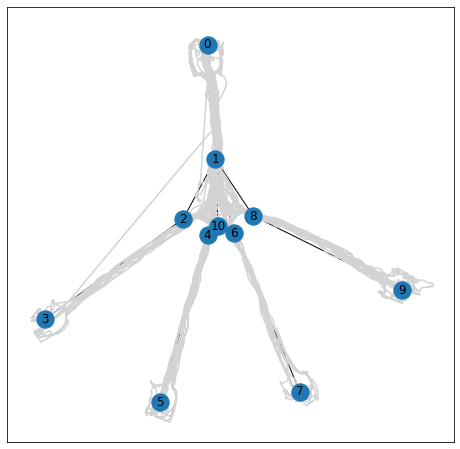

In [12]:
import track_linearization as ti


track_graph=ti.make_track_graph(node_positions, edges)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.plot(position_info.head_position_x, position_info.head_position_y, color='lightgrey')

ti.plot_track_graph(track_graph)

#### 2.3 do lumping for the center platform

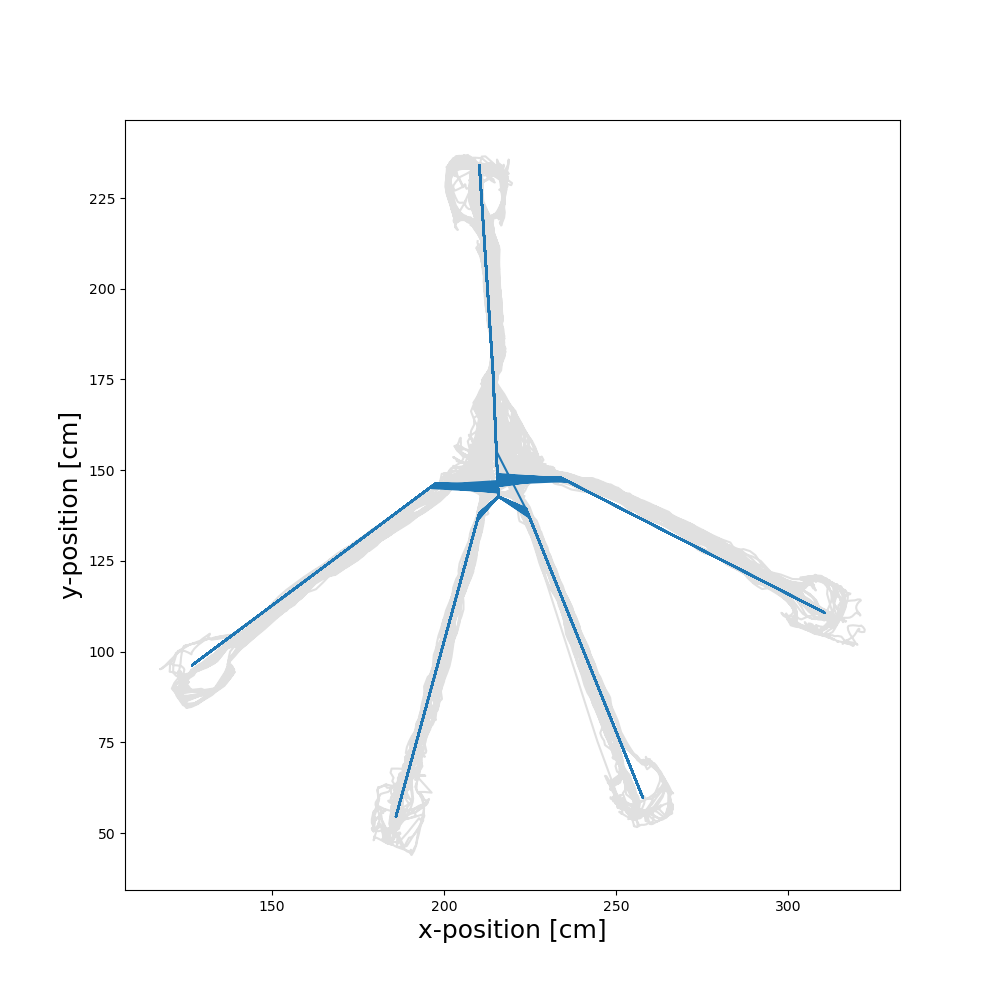

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.plot(position_info.head_position_x, position_info.head_position_y,
        color='lightgrey', alpha=0.7, zorder=0)
ax.set_xlabel('x-position [cm]', fontsize=18)
ax.set_ylabel('y-position [cm]', fontsize=18)
ax.plot(linear_position_df.projected_x_position, linear_position_df.projected_y_position)

(array([[  0.        ,  57.63896252],
        [ 57.63896252,  91.42227941],
        [131.42227941, 165.66041604],
        [165.66041604, 252.64353221],
        [292.64353221, 331.10211383],
        [331.10211383, 418.29227956],
        [458.29227956, 496.49241045],
        [496.49241045, 583.18763812],
        [623.18763812, 657.72023142],
        [657.72023142, 743.03215907]]),
 {'home': 0.0,
  'well1': 252.64353221468843,
  'well2': 418.292279561657,
  'well3': 583.1876381171415,
  'well4': 743.0321590705632})

In [44]:
graph.fetch('node_positions')

array([array([[210.25, 234.  ],
              [214.25, 176.5 ],
              [197.75, 146.5 ],
              [126.75,  96.25],
              [210.25, 138.25],
              [186.  ,  54.5 ],
              [223.75, 139.5 ],
              [257.75,  59.75],
              [233.75, 148.  ],
              [310.5 , 110.75],
              [215.75, 142.75]])], dtype=object)

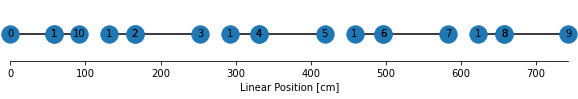

In [23]:
fig, ax = plt.subplots(figsize=(10, 1))
graph.plot_track_graph_as_1D(
    ax=ax)

In [37]:
graph.plot_track_graph_as_1D(
    ax=ax)

Text(0.5, 1.0, 'Linear Position')

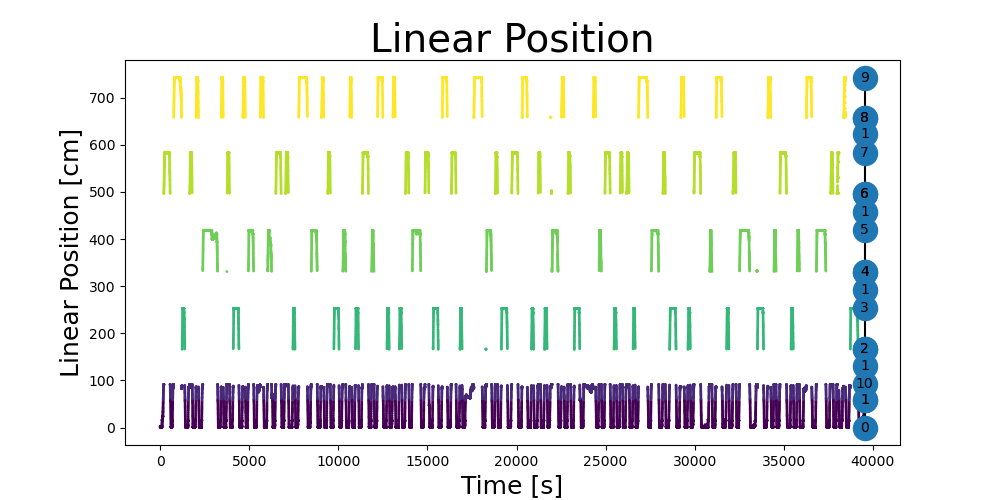

In [51]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(linear_position_df.index,
            linear_position_df.linear_position,
            c=linear_position_df.track_segment_id,
            s=1)
graph.plot_track_graph_as_1D(
    ax=ax,
    axis='y',
    other_axis_start=linear_position_df.index[-1] + 10)

ax.set_xlabel('Time [s]', fontsize=18)
ax.set_ylabel('Linear Position [cm]', fontsize=18)
ax.set_title('Linear Position', fontsize=28)

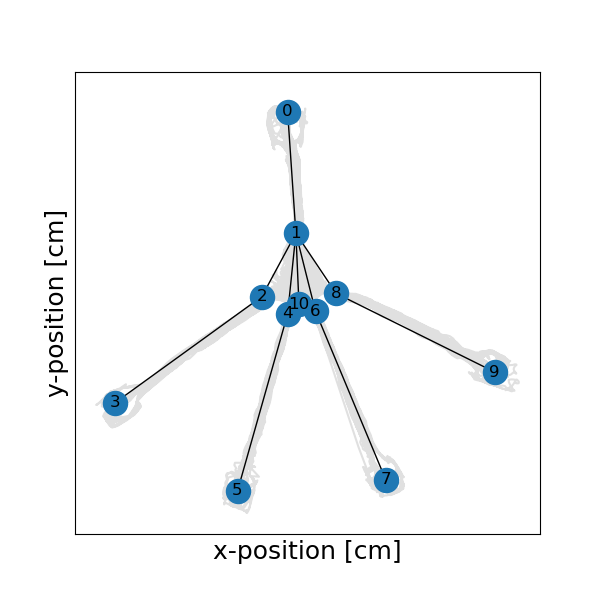

In [52]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.plot(position_info.head_position_x, position_info.head_position_y,
        color='lightgrey', alpha=0.7, zorder=0)
ax.set_xlabel('x-position [cm]', fontsize=18)
ax.set_ylabel('y-position [cm]', fontsize=18)
graph.plot_track_graph(ax=ax)

### Done! In the future, use ```{'track_graph_name':4 arm lumped}``` in the table ```IntervalLinearizationSelection```
Below are just examples. See other notebooks.

In [55]:
from spyglass.common.common_position import IntervalLinearizationSelection
from spyglass.common.common_position import IntervalLinearizedPosition


IntervalLinearizationSelection.insert1(
    {'position_info_param_name': 'default',
     'nwb_file_name': nwb_copy_file_name,
     'interval_list_name': 'pos 3 valid times',
     'track_graph_name': '4 arm lumped',
     'linearization_param_name': 'default'
    }, replace=True)


IntervalLinearizationSelection&{'nwb_file_name':nwb_copy_file_name}
IntervalLinearizedPosition().populate()


Computing linear position for: {'position_info_param_name': 'default', 'nwb_file_name': 'molly20220416_.nwb', 'interval_list_name': 'pos 3 valid times', 'track_graph_name': '4 arm lumped', 'linearization_param_name': 'default'}
Writing new NWB file molly20220416_MG7NT083FH.nwb


And then we can run the linearization by populating the `IntervalLinearizedPosition` table.

In [54]:
linear_position_df_spy= (IntervalLinearizedPosition() &
                     {'position_info_param_name': 'default',
                      'nwb_file_name': nwb_copy_file_name,
                      'interval_list_name': 'pos 3 valid times',
                      'track_graph_name': '4 arm lumped',
                      'linearization_param_name': 'default',
                     }).fetch1_dataframe()
linear_position_df_spy

,linear_position,track_segment_id,projected_x_position,projected_y_position
time,,,,
1.650141e+09,1.206866,0,210.333753,232.796044
1.650141e+09,1.157529,0,210.330330,232.845262
1.650141e+09,1.125541,0,210.328110,232.877173
1.650141e+09,1.035541,0,210.321864,232.966956
1.650141e+09,0.923854,0,210.314113,233.078373
...,...,...,...,...
1.650143e+09,22.163827,0,211.788114,211.889608
1.650143e+09,21.669370,0,211.753800,212.382873
1.650143e+09,21.351117,0,211.731714,212.700358


Text(0.5, 1.0, 'Linear Position')

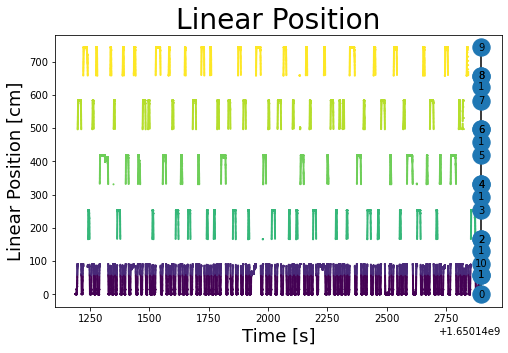

In [55]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(linear_position_df_spy.index,
            linear_position_df_spy.linear_position,
            c=linear_position_df_spy.track_segment_id,
            s=1)
graph.plot_track_graph_as_1D(
    ax=ax,
    axis='y',
    other_axis_start=linear_position_df_spy.index[-1] + 10)

ax.set_xlabel('Time [s]', fontsize=18)
ax.set_ylabel('Linear Position [cm]', fontsize=18)
ax.set_title('Linear Position', fontsize=28)
#plt.xlim(linear_position_df_spy.index[0],linear_position_df_spy.index[-1])